**Task 1** Parametrizations
\begin{align*}
	\mathbf{p}_1(t) &= (\cos t, \sin t, t) \\
	\textrm{and } \quad \mathbf{p}_2(t) &= (\sin t, \cos t, t) \quad \phantom{\textrm{in }}
\end{align*}
determine two _helices_ in $\mathbb{R}^3$. Find the points of intersection of these two curves. What is the angle of intersection at these points?

**Task 2** Find a parametrization of the epicycloid (and the hypocycloid), i.e., the curve formed by tracing a point on the circumference of a circle with radius $r$ which rolls around (inside) a fixed circle of radius $R$.

**Task 3: Intersection points of planar polygonal chains.** Write a _Julia_ function `crossing(A, B)` that determines whether two line segments $\overline{A_1 A_2}$ and $\overline{B_1 B_2}$ intersect and if so returns their intersection point. Both line segments are represented as a vector of 2-tuples; `[A1, A2] = [(x1, y1), (x2, y2)]`.

Two polygonal chains $K$ and $L$ are defined by the sequence of  line segments  $\overline{A_1 A_2}, \overline{A_2 A_3},\ldots$ and  $\overline{B_1 B_2}, \overline{B_2 B_3},\ldots$. Write a _Julia_ function `crossings(K, L)` that returns all the intersection points of the polygonal chains $K$ and $L$. The points that define the curves $K$ and $L$ and the return value $P$ are represented as vectors of consecutive 2-tuples that represent vertices of these polygonal chains.

In [4]:
function cross_product_2d(u, v)
    return u[1]*v[2] - u[2]*v[1]
end

function crossing(A, B)
    a, b = A
    c, d = B
    r = b .- a
    s = d .- c
    ca = c .- a 
    
    if cross_product_2d(r, s) == 0
        return nothing
    end
    
    t = cross_product_2d(ca, s) / cross_product_2d(r, s)
    u = cross_product_2d(ca, r) / cross_product_2d(r, s)

    if 0 <= t <= 1 && 0 <= u <= 1
        return a .+ t .* r 
    end
    
end

function crossings(K, L)
    C = Tuple{Float64, Float64}[]
    for i in 1:length(K)-1
        for j in 1:length(L)-1
            cr = crossing(K[i:i+1], L[j:j+1])
            if !isnothing(cr)
                push!(C, cr)
            end
        end
    end
    return C
end


crossings (generic function with 1 method)

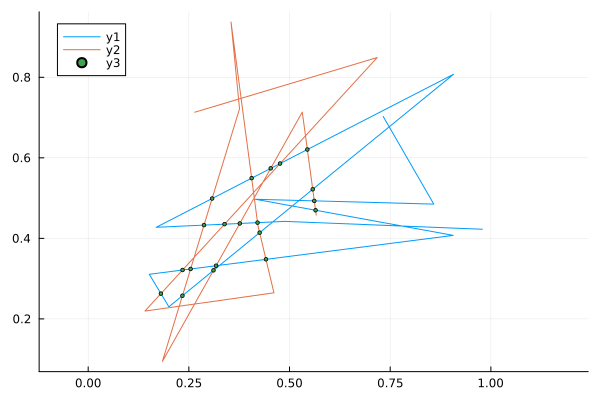

In [6]:
# a chack with two random poygonal chains
A = [(rand(), rand()) for _ in 1:10]
B = [(rand(), rand()) for _ in 1:10]
using Plots
# plot both chains
plot(A; ratio = 1)
plot!(B; ratio = 1)
# mark all intersection points
scatter!(crossings(A, B); markersize = 2)

**Task 4** Evaluate the length of one of the arcs of the cycloid given by $$\mathbf{q}(t) = [t - \sin t, 1 - \cos t]^\mathsf{T} \textrm{, } t \in [0, 2\pi] \textrm{. }$$ 
What is the area between the $x$-axis and one arc of the cycloid?

(A _cycloid_ is a curve traced by a point on the rim of a wheel rolling along the $x$-axis. The parametrization given above is for a circle with radius $r=1$.) 

**Task 5** A lemniscate is a curve with the parametrization $$\mathbf{p}(t) = \left[\frac{a \cos t}{1+\sin^2 t}, \frac{a \sin t \cos t}{1+\sin^2 t}\right]^\mathsf{T} \textrm{, } t \in [0, 2\pi] \textrm{. }$$

- Plot the lemniscate (for, e.g., $a = 1$).
- Evaluate the area of one of the regions enclosed by a loop.

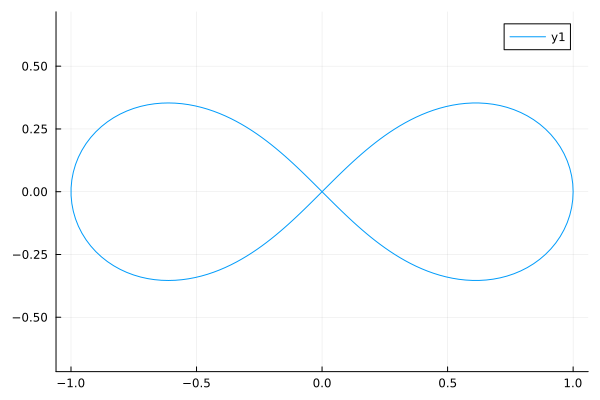

In [16]:
a = 1
p(t) = (a .* cos.(t) ./ (1 .+ sin.(t) .^ 2), (a .* sin.(t) .* cos.(t)) ./ (1 .+ sin.(t) .^ 2))
tr = LinRange(0, 2*pi, 200)
lemniskata = plot(p(tr), ratio=1)

**Task 5: The circumference and the area of a planar polygon.** A polygon $P$ in $\mathbb{R}^2$ is determined by a sequence of points $A_1,A_2, \ldots, A_k$. Write _Julia_ functions `circumference(P)` and `area(P)` that return the circumference and the area of the polygon $P$. The polygon is given as a vector of 2-tuples.

_Additional task:_ Both functions should verify that the points $A_1,A_2, \ldots, A_k$ do indeed represent a polygon. 

In [21]:
using LinearAlgebra
function circumference(P)
    c = 0.0

    for point in 1:length(P)-1
        len = norm(collect(P[point+1])-collect(P[point]))
        c += len
    end
    
    return c+norm(collect(P[end])-collect(P[1]))
end

function area(P)
    A = 0
    for k in 2:(lastindex(P)-1)
        # add the signed area of the triangle A1AkA(k+1) to A
        A = A + 0.5*det([collect(P[k])-collect(P[1]) collect(P[k+1])-collect(P[1])])
    end

    return A
    
end

area (generic function with 1 method)

In [22]:
P = [(0,0), (1, 0), (1, 1), (0.5, 0.5), (0, 1)]
circumference(P), area(P)

(4.414213562373095, 0.75)